In [1]:
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
from collections import defaultdict
import json

# Load your data
with open("mention_networks/network_mega_merge.json", "r", encoding="utf-8") as f:
    edges = json.load(f)

# Step 1: Build Graph
G = nx.Graph()
G.add_edges_from(edges)

# Step 2: Louvain Community Detection
partition = community_louvain.best_partition(G)

# Organize nodes by communities
clusters = defaultdict(list)
for node, comm_id in partition.items():
    clusters[comm_id].append(node)

# Step 3: Compute centrality (degree or betweenness)
degree_centrality = nx.degree_centrality(G)

# Step 4: Find top N most important nodes in each community
top_accounts_per_cluster = {}
for comm_id, nodes in clusters.items():
    sorted_nodes = sorted(nodes, key=lambda x: degree_centrality[x], reverse=True)
    top_accounts_per_cluster[comm_id] = sorted_nodes[:5]  # Top 5 accounts

# Optional: Visualize the graph
# pos = nx.spring_layout(G)
# cmap = plt.get_cmap("tab20")
# nx.draw_networkx_nodes(G, pos, node_color=[partition[n] for n in G.nodes()], cmap=cmap, node_size=40)
# nx.draw_networkx_edges(G, pos, alpha=0.5)
# plt.show()

# Print Results
print("Detected Communities and Top Accounts:\n")
for comm_id, top_accounts in top_accounts_per_cluster.items():
    print(f"Community {comm_id} ({len(clusters[comm_id])} accounts):")
    for account in top_accounts:
        print(f"   - {account} (centrality: {degree_centrality[account]:.4f})")
    print()


Detected Communities and Top Accounts:

Community 0 (105 accounts):
   - pensiabls (centrality: 0.0012)
   - shakywf (centrality: 0.0009)
   - donnietheguy (centrality: 0.0007)
   - littlemiafox (centrality: 0.0007)
   - dailyoni (centrality: 0.0007)

Community 11 (127 accounts):
   - siriusxm (centrality: 0.0013)
   - starboyrob (centrality: 0.0012)
   - theweeknd (centrality: 0.0009)
   - wuwa_verse1 (centrality: 0.0007)
   - finnaflex (centrality: 0.0006)

Community 40 (98 accounts):
   - levelsio (centrality: 0.0009)
   - oreillymedia (centrality: 0.0007)
   - jorgecastillopr (centrality: 0.0007)
   - googleuk (centrality: 0.0007)
   - shpigford (centrality: 0.0006)

Community 3 (227 accounts):
   - hibzster (centrality: 0.0007)
   - criticaloverlo3 (centrality: 0.0007)
   - sadhotgiri (centrality: 0.0007)
   - zazamyodor (centrality: 0.0007)
   - soioucity (centrality: 0.0007)

Community 7 (291 accounts):
   - fulufuluu (centrality: 0.0008)
   - 8ballswwife (centrality: 0.0008)
  

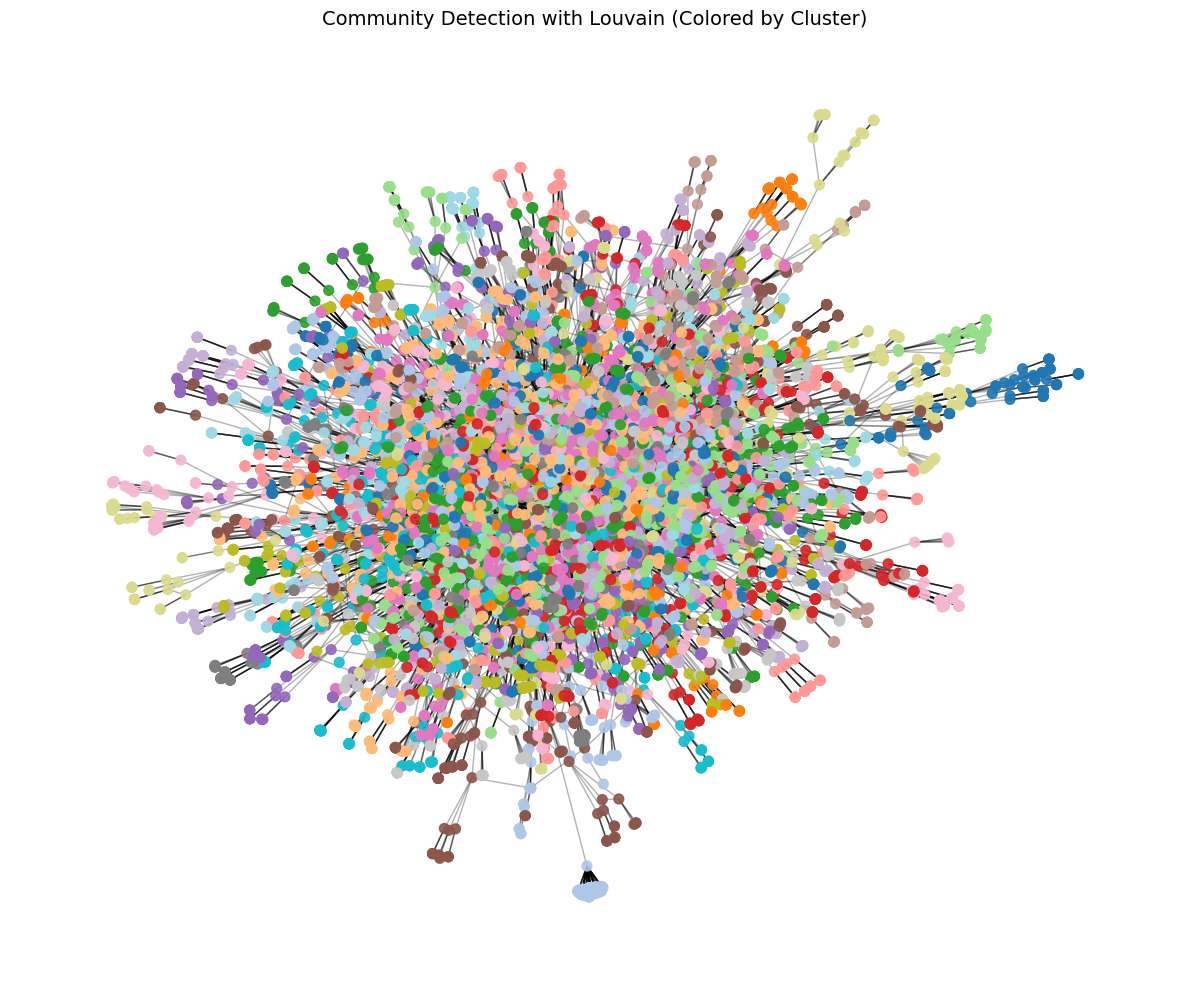

In [3]:
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import json

# Load the dataset (replace with your actual filename or variable)
with open("mention_networks/network_mega_merge.json", "r", encoding="utf-8") as f:
    edges = json.load(f)

# Step 1: Build the graph
G = nx.Graph()
G.add_edges_from(edges)

# Step 2: Community detection using Louvain
partition = community_louvain.best_partition(G)

# Step 3: Visualize communities
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)  # Fixed seed for consistent layout
cmap = plt.get_cmap("tab20")  # Up to 20 distinct colors

# Draw nodes with color based on their community
node_colors = [partition[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=50, node_color=node_colors, cmap=cmap, alpha=0.9)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.3)

plt.title("Community Detection with Louvain (Colored by Cluster)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()
